# Optimizing a LightGBM model with the native API

Notebook for the course [Master Hyperparameter Optimization for Tabular Learning](http://www.trainindata.com/p/master-hyperparameter-optimization-for-tabular-learning)

Optuna is framework agnostic. That means that it can optimise the hyperparameters of any model, from any library, provided we can set that up in our objective function.

In this notebook, we optimize the hyperparameters of a [LightGBM](https://lightgbm.readthedocs.io/) classifier using Optuna's define-by-run API and LightGBM's native training API.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import lightgbm as lgb

import optuna

# Data Preparation

We use the breast cancer dataset, the same one used throughout this section, so results are easy to compare across notebooks.

In [2]:
# load dataset

X, y = load_breast_cancer(return_X_y=True, as_frame=True)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# split dataset into a train and test set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

X_train.shape, X_test.shape

((455, 30), (114, 30))

# Define-by-Run design

We define the LightGBM hyperparameter space and evaluate each configuration with 5-fold cross-validation using LightGBM's native API.

In [4]:
train_data = lgb.Dataset(X_train, label=y_train, free_raw_data=False)


def objective(trial):

    num_boost_round = trial.suggest_int("num_boost_round", 50, 500)

    params = {
        "objective": "binary",
        "metric": ["auc", "binary_logloss"],
        "verbosity": -1,
        "num_leaves": trial.suggest_int("num_leaves", 2, 256, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 100),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": 1,
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "feature_pre_filter": False,
        "seed": 0,
    }

    cv_results = lgb.cv(
        params=params,
        train_set=train_data,
        num_boost_round=num_boost_round,
        nfold=5,
        stratified=True,
        shuffle=True,
        seed=0,
    )


    # Enriching the search results with more metrics
    roc_auc_mean = cv_results["valid auc-mean"][-1]
    roc_auc_std = cv_results["valid auc-stdv"][-1]

    logloss_mean = cv_results["valid binary_logloss-mean"][-1]
    logloss_std = cv_results["valid binary_logloss-stdv"][-1]

    # number of completed boosting rounds
    n_rounds = len(cv_results["valid auc-mean"])

    # pass the results to the trials
    trial.set_user_attr("roc_auc_mean", roc_auc_mean)
    trial.set_user_attr("roc_auc_std", roc_auc_std)
    trial.set_user_attr("logloss_mean", logloss_mean)
    trial.set_user_attr("logloss_std", logloss_std)
    trial.set_user_attr("completed_boosting_rounds", n_rounds)

    return roc_auc_mean

In [5]:
# we save the study to disk, so we can load and evaluate it
# in the next notebook

study_name = "lightgbm_study"
storage_name = "sqlite:///{}.db".format(study_name)

In [6]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=0),
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,
)

study.optimize(objective, n_trials=30)

[I 2026-08-26 13:08:57,396] A new study created in RDB with name: lightgbm_study
[I 2026-08-26 13:08:58,267] Trial 0 finished with value: 0.9899686520376176 and parameters: {'num_boost_round': 297, 'num_leaves': 59, 'max_depth': 8, 'learning_rate': 0.022373901095679754, 'min_data_in_leaf': 45, 'bagging_fraction': 0.8229470565333281, 'feature_fraction': 0.7187936056313462, 'lambda_l1': 1.0615904599004025, 'lambda_l2': 4.7093920302768835}. Best is trial 0 with value: 0.9899686520376176.
[I 2026-08-26 13:08:58,638] Trial 1 finished with value: 0.9867293625914316 and parameters: {'num_boost_round': 222, 'num_leaves': 88, 'max_depth': 7, 'learning_rate': 0.02553378845151235, 'min_data_in_leaf': 93, 'bagging_fraction': 0.5355180290989434, 'feature_fraction': 0.5435646498507704, 'lambda_l1': 1.5204270129130175e-08, 'lambda_l2': 0.31158648353398066}. Best is trial 0 with value: 0.9899686520376176.
[I 2026-08-26 13:08:59,923] Trial 2 finished with value: 0.9926854754440961 and parameters: {'num

# Analyze results

In [7]:
study.best_params

{'num_boost_round': 459,
 'num_leaves': 7,
 'max_depth': 11,
 'learning_rate': 0.07083166076835339,
 'min_data_in_leaf': 22,
 'bagging_fraction': 0.9298743667456382,
 'feature_fraction': 0.6071813007582153,
 'lambda_l1': 0.00018672903987723076,
 'lambda_l2': 0.001132215415478857}

In [8]:
study.best_value

0.9934169278996865

In [9]:
def plot_metric_with_std(study, metric):

    labels = {"roc_auc": "ROC AUC", "logloss": "Log loss"}
    mean_key = f"{metric}_mean"
    std_key = f"{metric}_std"

    # Some trials may predate the addition of these user attributes.
    trials = [trial for trial in study.trials if mean_key in trial.user_attrs]

    plt.errorbar(
        [trial.number for trial in trials],
        [trial.user_attrs[mean_key] for trial in trials],
        yerr=[trial.user_attrs[std_key] for trial in trials],
        fmt="o",
        capsize=3,
    )
    plt.xlabel("Trial")
    plt.ylabel(labels[metric])
    plt.title(f"{labels[metric]} by Optuna trial")
    plt.show()

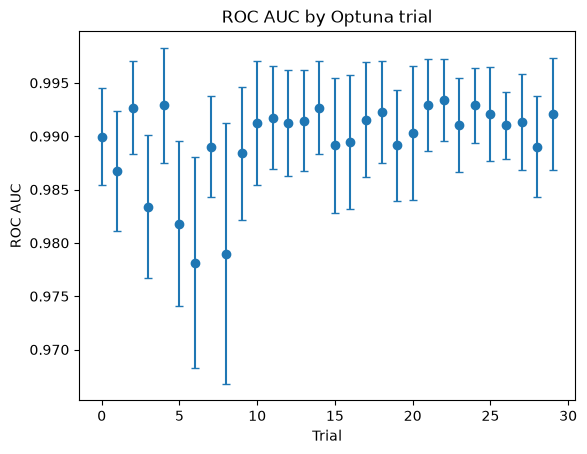

In [10]:
plot_metric_with_std(study, metric="roc_auc")

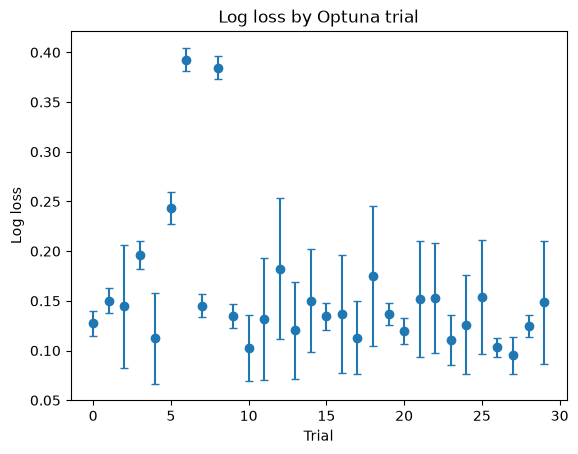

In [11]:
plot_metric_with_std(study, metric="logloss")

# Evaluate the model

In [12]:
# retrain on the full training set with the best hyperparameters

best_params = study.best_params.copy()
num_boost_round = best_params.pop("num_boost_round")
best_params.update(objective="binary", metric="auc", verbosity=-1, bagging_freq=1)

final_model = lgb.train(
    params=best_params,
    train_set=lgb.Dataset(X_train, label=y_train),
    num_boost_round=num_boost_round,
)

y_pred_proba = final_model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(np.int8)

accuracy_score(y_test, y_pred)

0.9912280701754386